# MLP/CNN Model Learning Examples

This is my first AI notebook!

Import libraries:

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

Load the dataset:

In [2]:
(train_data, train_validation_data), (test_data, test_validation_data) = keras.datasets.mnist.load_data()

Inspect the data:

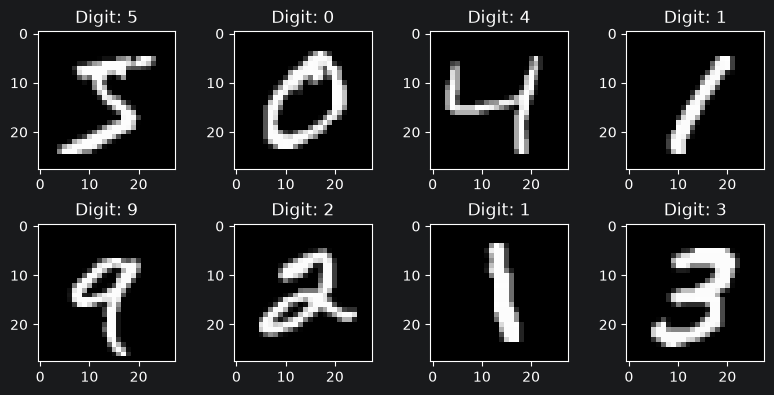

In [3]:
EXAMPLE_LAYOUT_WIDTH = 4
EXAMPLE_LAYOUT_HEIGHT = 2

plt.figure(figsize=(EXAMPLE_LAYOUT_WIDTH * 2, EXAMPLE_LAYOUT_HEIGHT * 2))

for index in range(EXAMPLE_LAYOUT_WIDTH * EXAMPLE_LAYOUT_HEIGHT):
    title = f'Digit: {train_validation_data[index]}'

    plt.subplot(EXAMPLE_LAYOUT_HEIGHT, EXAMPLE_LAYOUT_WIDTH, index + 1, title=title)
    plt.imshow(train_data[index], cmap='gray')

plt.tight_layout()
plt.show()

Normalize pixel values:

In [4]:
train_data_normalized = train_data / 255.0
test_data_normalized = test_data / 255.0

Configure and train the model:

In [5]:
model_mlp = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation="softmax"),
])

model_mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_mlp.fit(train_data_normalized, train_validation_data)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step - accuracy: 0.9268 - loss: 0.2598


Evaluate the MLP model:

In [6]:
model_mlp_loss, model_mpl_accuracy = model_mlp.evaluate(test_data_normalized, test_validation_data)

print(f'MLP loss: {model_mlp_loss:.4f}')
print(f'MLP accuracy: {model_mpl_accuracy:.2%}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - accuracy: 0.9557 - loss: 0.1510
MLP loss: 0.1510
MLP accuracy: 95.57%


Same task with a CNN architecture:

In [7]:
model_cnn = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax"),
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn.fit(train_data_normalized, train_validation_data)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9510 - loss: 0.1592


In [8]:
model_cnn_loss, model_cnn_accuracy = model_cnn.evaluate(test_data_normalized, test_validation_data)

print(f'CNN loss: {model_cnn_loss:.4f}')
print(f'CNN accuracy: {model_cnn_accuracy:.2%}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9870 - loss: 0.0387
CNN loss: 0.0387
CNN accuracy: 98.70%


Print learning summary:

In [9]:
model_mlp.summary()
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)